# Streaming ASR, visualised

A companion to `demo.py`. Each section re-runs one demo step, then draws it so the
mechanics are visible rather than just printed. Every section ends with a few
**Try this** prompts: change a number, re-run, and predict the picture before you look.

Sections follow the demo:

1. Causality (convolution and normalisation)
2. Chunked attention masks
3. Streaming Conformer block = offline block
4. Transducer lattice and the delay penalty
5. CTC decoding, right and wrong
6. The four latencies
7. Endpointing
8. KV cache memory

Run with the **Python (streaming-asr)** kernel.

In [22]:
# Pick up edits to streaming_asr/*.py without restarting the kernel
%load_ext autoreload
%autoreload 2

import itertools

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from cycler import cycler
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

from streaming_asr.cache import kv_cache_bytes
from streaming_asr.causality import (
    CausalDepthwiseConv1d,
    CentredDepthwiseConv1d,
    RunningCMVN,
    utterance_cmvn,
)
from streaming_asr.conformer import StreamingConformerBlock
from streaming_asr.ctc import (
    ctc_greedy_decode,
    ctc_greedy_decode_buggy,
    ctc_loss_forward,
    peaky_fraction,
)
from streaming_asr.endpointing import EndpointConfig, Endpointer
from streaming_asr.latency import (
    awed,
    effective_latency,
    emission_delays,
    frames_to_seconds,
    user_perceived_turn_latency,
)
from streaming_asr.masks import (
    algorithmic_delay_seconds,
    causal_mask,
    chunk_mask,
    full_mask,
    max_key_index,
)
from streaming_asr.transducer import num_alignments, rnnt_loss, rnnt_loss_bruteforce

FRAME_MS = 40.0  # 10 ms features, subsampled by 4

# --- plot style -------------------------------------------------------------
# Series colours, always used in this order
BLUE, ORANGE, AQUA, YELLOW, MAGENTA = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"
SURFACE, INK, INK_2, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
NEUTRAL = "#f0efec"

SEQ = LinearSegmentedColormap.from_list(
    "seq_blue", [SURFACE, "#cde2fb", "#6da7ec", "#256abf", "#0d366b"]
)
MASK_CMAP = ListedColormap([NEUTRAL, BLUE])  # False / True

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110, "font.size": 10,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK_2, "text.color": INK,
    "axes.titlesize": 11, "axes.titlelocation": "left", "axes.titlepad": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "lines.linewidth": 2, "lines.markersize": 6,
    "legend.frameon": False,
    "axes.prop_cycle": cycler(color=[BLUE, ORANGE, AQUA, YELLOW, MAGENTA]),
})


def matrix_ax(ax, n, step=None):
    # Tidy an ax showing an n x n boolean matrix, with optional chunk boundaries
    ax.grid(False)
    ax.set_xticks(range(0, n, 4))
    ax.set_yticks(range(0, n, 4))
    ax.plot([-0.5, n - 0.5], [-0.5, n - 0.5], color=INK, lw=0.8, ls="--")  # i == j: "now"
    if step:
        for b in range(step, n, step):
            ax.axhline(b - 0.5, color=SURFACE, lw=1.5)
            ax.axvline(b - 0.5, color=SURFACE, lw=1.5)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Causality is a property you can measure

A layer is causal if the output at frame *t* does not change when you change frames after *t*.
The demo checks this at one frame. Here we check every frame, then draw the full
**receptive field**: which input frames each output frame actually reads.

change at t=10   centred 0.9726   causal 0.0000


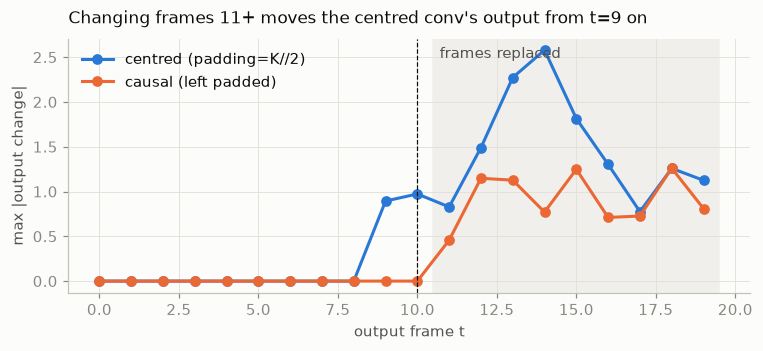

In [25]:
torch.manual_seed(0)
T, C, K = 20, 4, 5
x = torch.randn(1, C, T)
future = x.clone()
future[..., 11:] = torch.randn_like(future[..., 11:])  # replace every frame after t=10

centred = CentredDepthwiseConv1d(C, K).eval()
causal = CausalDepthwiseConv1d(C, K).eval()

with torch.no_grad():
    # largest change over channels, at every output frame
    d_centred = (centred(x) - centred(future)).abs().amax(dim=1).squeeze(0)
    d_causal = (causal(x) - causal(future)).abs().amax(dim=1).squeeze(0)

print(f"change at t=10   centred {d_centred[10]:.4f}   causal {d_causal[10]:.4f}")

fig, ax = plt.subplots(figsize=(8, 3))
ax.axvspan(10.5, T - 0.5, color=NEUTRAL, zorder=0)
ax.plot(d_centred, marker="o", label=f"centred (padding=K//2)")
ax.plot(d_causal, marker="o", label="causal (left padded)")
ax.axvline(10, color=INK, lw=0.8, ls="--")
ax.set(xlabel="output frame t", ylabel="max |output change|",
       title="Changing frames 11+ moves the centred conv's output from t=9 on")
ax.text(10.7, ax.get_ylim()[1] * 0.92, "frames replaced", color=INK_2)
ax.legend(loc="upper left")
plt.show()

The centred kernel reads `K//2 = 2` frames ahead, so outputs at t=9 and t=10 move even though
their inputs did not. Below, the Jacobian ∂y[t]/∂x[s] makes this explicit: the blue band is
everything frame *t* depends on. Anything right of the dashed diagonal is the future.

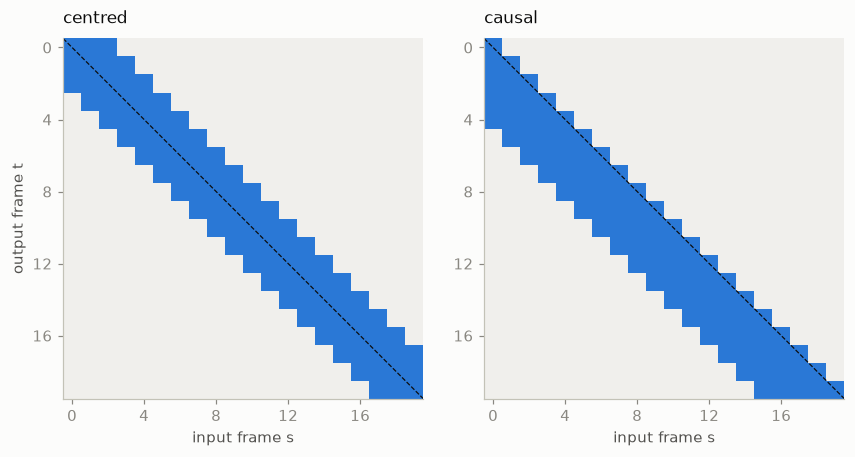

In [26]:
def receptive_field(module, T=20, C=4):
    # |dy[t]/dx[s]| summed over channels -> (T_out, T_in) dependency matrix
    x = torch.randn(1, C, T)
    J = torch.autograd.functional.jacobian(module, x)  # (1, C, T, 1, C, T)
    return J.abs().sum(dim=(0, 1, 3, 4)) > 0


fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, (name, m) in zip(axes, {"centred": centred, "causal": causal}.items()):
    ax.imshow(receptive_field(m), cmap=MASK_CMAP, vmin=0, vmax=1)
    matrix_ax(ax, T)
    ax.set(title=name, xlabel="input frame s")
axes[0].set_ylabel("output frame t")
plt.tight_layout()
plt.show()

### The violation people forget: normalisation

Per-utterance CMVN normalises with the mean and variance of the *whole* utterance, so a loud
stretch at the end changes how frame 0 is normalised. `RunningCMVN` only uses frames `0..t`.

running CMVN, streaming vs offline: max diff 4.77e-07


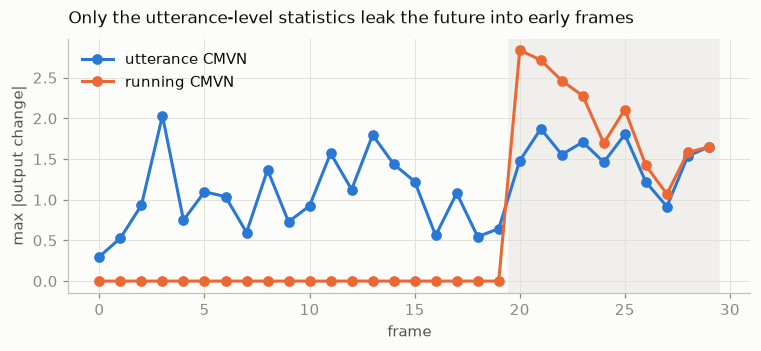

In [27]:
torch.manual_seed(1)
feats = torch.randn(1, 30, 4)          # (B, T, C)
louder = feats.clone()
louder[:, 20:] += 3.0                  # loud audio arrives at frame 20

running = RunningCMVN()
d_utt = (utterance_cmvn(feats) - utterance_cmvn(louder)).abs().amax(-1).squeeze(0)
d_run = (running(feats) - running(louder)).abs().amax(-1).squeeze(0)

# The streaming path, fed 7 frames at a time, must match the offline one
state, outs = running.init_state(1, 4), []
for s in range(0, 30, 7):
    y, state = running.step(feats[:, s:s + 7], state)
    outs.append(y)
print(f"running CMVN, streaming vs offline: max diff {(torch.cat(outs, 1) - running(feats)).abs().max():.2e}")

fig, ax = plt.subplots(figsize=(8, 3))
ax.axvspan(19.5, 29.5, color=NEUTRAL, zorder=0)
ax.plot(d_utt, marker="o", label="utterance CMVN")
ax.plot(d_run, marker="o", label="running CMVN")
ax.set(xlabel="frame", ylabel="max |output change|",
       title="Only the utterance-level statistics leak the future into early frames")
ax.legend(loc="upper left")
plt.show()

**Try this**
- Change `K` to 9. How many future frames does the centred conv read now?
- Feed `CausalDepthwiseConv1d.step` chunks of 3 frames and confirm it matches `forward`.
- In the CMVN cell, make the change at frame 2 instead of 20. Why does running CMVN react so strongly early on?

## 2. The attention policy is one boolean matrix

`mask[i, j] == True` means query frame *i* may attend to key frame *j*. White lines mark chunk
boundaries, and the dashed diagonal is "now". Blue to the right of the diagonal is lookahead,
which costs latency. Blue to the left is history, which costs memory.

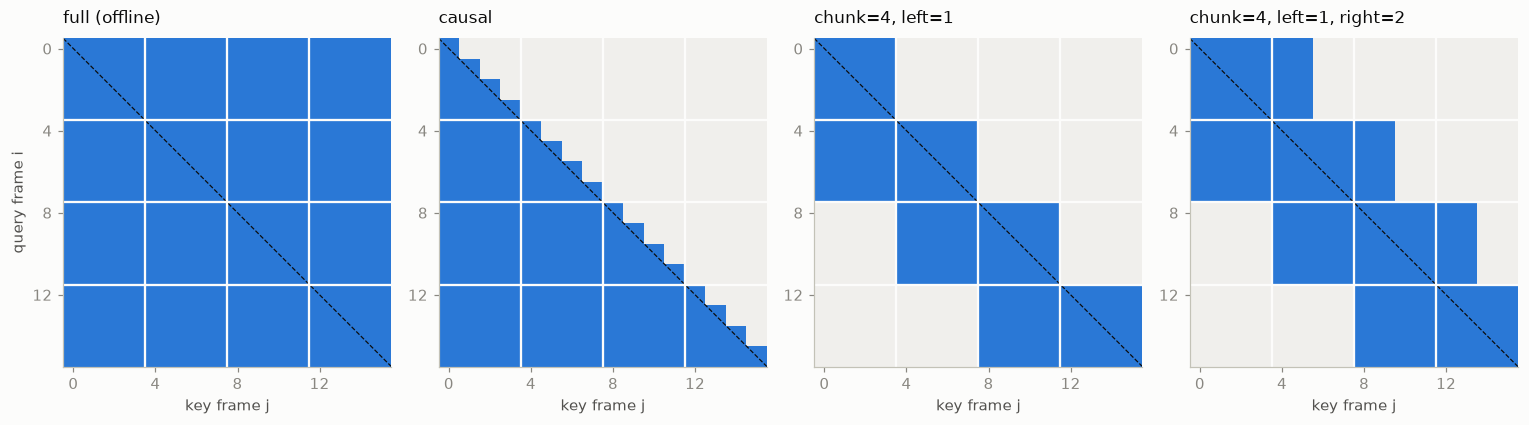

In [28]:
T, CHUNK, LEFT = 16, 4, 1
masks = {
    "full (offline)": full_mask(T),
    "causal": causal_mask(T),
    f"chunk={CHUNK}, left={LEFT}": chunk_mask(T, CHUNK, LEFT),
    f"chunk={CHUNK}, left={LEFT}, right=2": chunk_mask(T, CHUNK, LEFT, right_context_frames=2),
}

fig, axes = plt.subplots(1, 4, figsize=(14, 3.9))
for ax, (name, m) in zip(axes, masks.items()):
    ax.imshow(m, cmap=MASK_CMAP, vmin=0, vmax=1)
    matrix_ax(ax, T, step=CHUNK)
    ax.set(title=name, xlabel="key frame j")
axes[0].set_ylabel("query frame i")
plt.tight_layout()
plt.show()

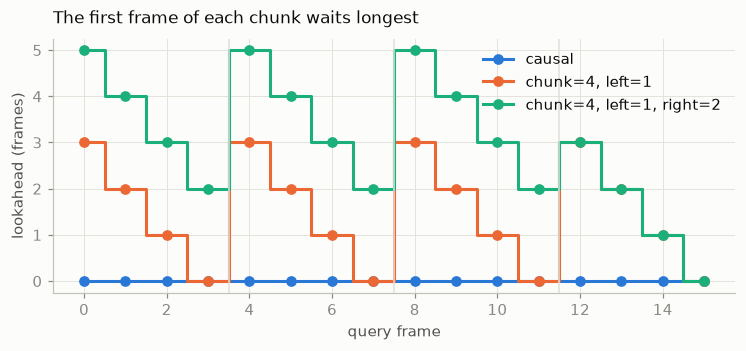

lookahead per frame: [3, 2, 1, 0, 3, 2, 1, 0, 3, 2, 1, 0, 3, 2, 1, 0]


In [29]:
frames = torch.arange(T)
fig, ax = plt.subplots(figsize=(8, 3))
for name in list(masks)[1:]:
    lookahead = max_key_index(masks[name]) - frames
    ax.plot(frames, lookahead, marker="o", drawstyle="steps-mid", label=name)
for b in range(CHUNK, T, CHUNK):
    ax.axvline(b - 0.5, color=GRID, lw=1)
ax.set(xlabel="query frame", ylabel="lookahead (frames)",
       title="The first frame of each chunk waits longest")
ax.legend(loc="upper right")
plt.show()

print("lookahead per frame:", (max_key_index(masks[f"chunk={CHUNK}, left={LEFT}"]) - frames).tolist())

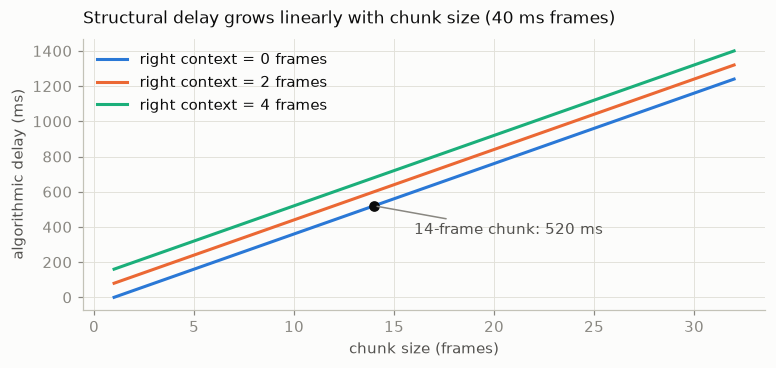

In [30]:
sizes = np.arange(1, 33)
fig, ax = plt.subplots(figsize=(8, 3.2))
for rc in (0, 2, 4):
    ax.plot(sizes, [algorithmic_delay_seconds(c, FRAME_MS, rc) * 1000 for c in sizes],
            label=f"right context = {rc} frames")
d14 = algorithmic_delay_seconds(14, FRAME_MS) * 1000
ax.plot([14], [d14], "o", color=INK)
ax.annotate(f"14-frame chunk: {d14:.0f} ms", (14, d14), xytext=(16, d14 - 160),
            color=INK_2, arrowprops=dict(arrowstyle="-", color=MUTED))
ax.set(xlabel="chunk size (frames)", ylabel="algorithmic delay (ms)",
       title=f"Structural delay grows linearly with chunk size ({FRAME_MS:.0f} ms frames)")
ax.legend(loc="upper left")
plt.show()

**Try this**
- Set `LEFT = None` (unlimited history). Which part of the picture changes, and does the lookahead plot change at all?
- What chunk size gives the same worst-case delay as `chunk=4, right=2`?

## 3. Streaming a Conformer block equals running it offline

Same weights and same input, two code paths: `block(x)` uses the chunk mask over the whole
utterance, and `block.stream(x)` feeds one chunk at a time and carries a KV cache plus conv state.
As a control, we also run the offline path with a **full** mask, which a streaming system can never match.

chunk mask vs streaming: max diff 4.77e-07
full mask  vs streaming: max diff 2.35e-01


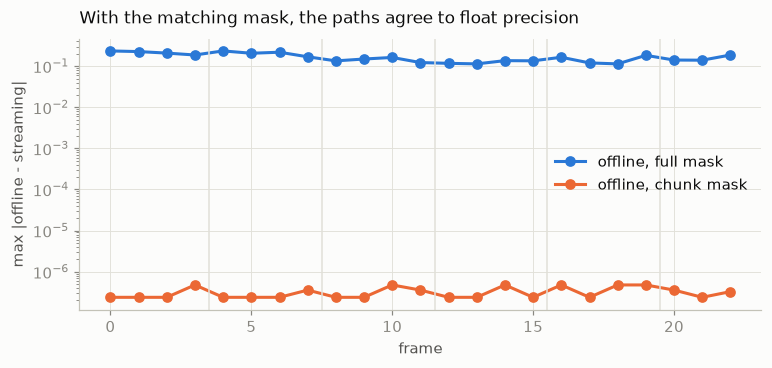

In [31]:
torch.manual_seed(0)
block = StreamingConformerBlock(
    d_model=32, num_heads=4, conv_kernel=5, ff_expansion=2,
    chunk_size=4, left_context_chunks=2,
).eval()
x = torch.randn(1, 23, 32)  # 23 frames: a partial final chunk on purpose

with torch.no_grad():
    offline = block(x)
    streaming = block.stream(x)
    offline_full = block(x, mask=full_mask(x.shape[1]))

err_chunk = (offline - streaming).abs().amax(-1).squeeze(0)
err_full = (offline_full - streaming).abs().amax(-1).squeeze(0)
print(f"chunk mask vs streaming: max diff {err_chunk.max():.2e}")
print(f"full mask  vs streaming: max diff {err_full.max():.2e}")

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.semilogy(err_full.clamp_min(1e-12), marker="o", label="offline, full mask")
ax.semilogy(err_chunk.clamp_min(1e-12), marker="o", label="offline, chunk mask")
for b in range(block.chunk_size, x.shape[1], block.chunk_size):
    ax.axvline(b - 0.5, color=GRID, lw=1)
ax.set(xlabel="frame", ylabel="max |offline - streaming|",
       title="With the matching mask, the paths agree to float precision")
ax.legend(loc="center right")
plt.show()

### What the stream carries between chunks

The KV cache grows until it holds `left_context_chunks + 1` chunks, then stays flat. That bound is
why one server can hold thousands of streams.

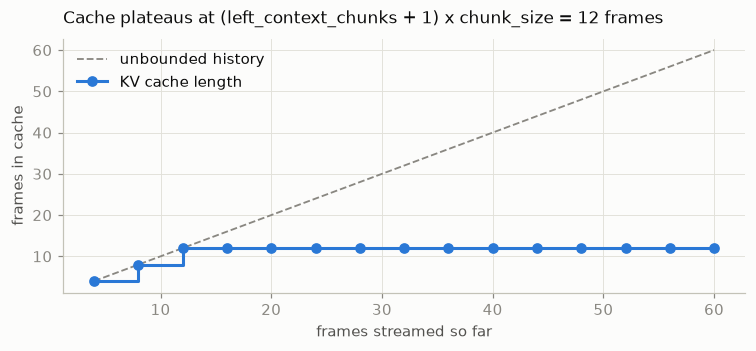

In [32]:
x_long = torch.randn(1, 60, 32)
state = block.init_state(1)
seen, cached = [], []
with torch.no_grad():
    for start in range(0, x_long.shape[1], block.chunk_size):
        _, state = block.step(x_long[:, start:start + block.chunk_size], state)
        seen.append(state["frames_seen"])
        cached.append(len(state["kv"]))

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(seen, seen, ls="--", color=MUTED, lw=1.2, label="unbounded history")
ax.plot(seen, cached, marker="o", drawstyle="steps-post", label="KV cache length")
ax.set(xlabel="frames streamed so far", ylabel="frames in cache",
       title=f"Cache plateaus at (left_context_chunks + 1) x chunk_size = "
             f"{(block.left_context_chunks + 1) * block.chunk_size} frames")
ax.legend(loc="upper left")
plt.show()

**Try this**
- Set `left_context_chunks=0`. Does streaming still match offline? Where does the cache plateau?
- Break it on purpose: in `conformer.py`, swap `CausalDepthwiseConv1d` for `CentredDepthwiseConv1d`.
  With autoreload on, re-run the cell and see which frames diverge. Revert afterwards.

## 4. The transducer loss sums over every alignment

Lattice nodes are `(t, u)`: *t* frames consumed and *u* labels emitted. A blank moves right and a
label moves up. Every monotonic staircase from `(0, 0)` to `(T-1, U)` is a valid alignment of the
same transcript. Below, each path is drawn with thickness proportional to its posterior probability.

20 paths enumerated: 20
forward recursion   9.874609
brute force         9.874609
-logsumexp(paths)   9.874609


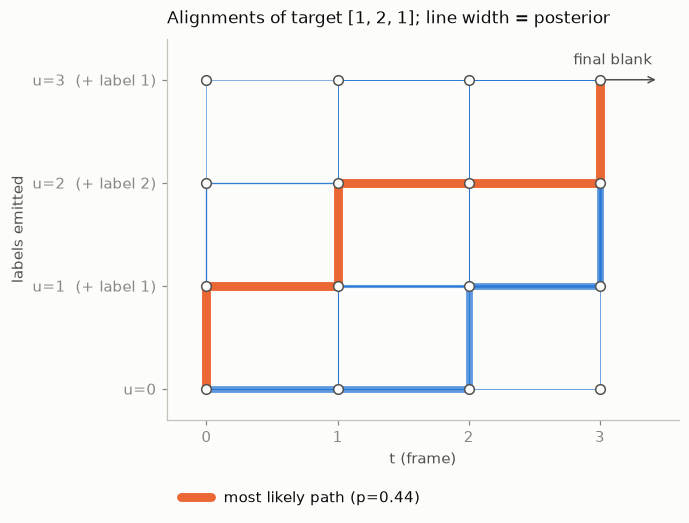

In [33]:
def enumerate_paths(lp, targets, blank=0, delay_penalty=0.0):
    # Every alignment as (nodes, label_frames, log score). Mirrors rnnt_loss_bruteforce.
    T, U = lp.shape[0], len(targets)
    paths = []
    for label_steps in itertools.combinations(range(T - 1 + U), U):
        t = u = 0
        nodes, label_frames, score = [(0, 0)], [], 0.0
        for step in range(T - 1 + U):
            if step in label_steps:
                score += float(lp[t, u, targets[u]]) - delay_penalty * t
                label_frames.append(t)
                u += 1
            else:
                score += float(lp[t, u, blank])
                t += 1
            nodes.append((t, u))
        score += float(lp[t, u, blank])  # the final blank
        paths.append((nodes, label_frames, score))
    return paths


T, U, V = 4, 3, 5
g = torch.Generator().manual_seed(0)
lp = torch.randn(T, U + 1, V, generator=g).log_softmax(dim=-1)
targets = torch.tensor([1, 2, 1])

paths = enumerate_paths(lp, targets)
scores = torch.tensor([s for *_, s in paths])
post = (scores - scores.logsumexp(0)).exp()

print(f"{num_alignments(T, U)} paths enumerated: {len(paths)}")
print(f"forward recursion   {float(rnnt_loss(lp[None], targets[None])):.6f}")
print(f"brute force         {float(rnnt_loss_bruteforce(lp, targets)):.6f}")
print(f"-logsumexp(paths)   {float(-scores.logsumexp(0)):.6f}")

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.grid(False)
best = int(post.argmax())
for i, (nodes, _, _) in enumerate(paths):
    ts, us = zip(*nodes)
    if i != best:
        ax.plot(ts, us, color=BLUE, lw=0.5 + 12 * float(post[i]), alpha=0.75, solid_capstyle="round")
ts, us = zip(*paths[best][0])
ax.plot(ts, us, color=ORANGE, lw=0.5 + 12 * float(post[best]), solid_capstyle="round",
        label=f"most likely path (p={post[best]:.2f})")
ax.annotate("", xy=(T - 0.55, U), xytext=(T - 1, U),
            arrowprops=dict(arrowstyle="->", color=INK_2))
ax.text(T - 0.6, U + 0.15, "final blank", color=INK_2, ha="right")
tt, uu = np.meshgrid(range(T), range(U + 1))
ax.scatter(tt, uu, s=40, color=SURFACE, edgecolor=INK_2, zorder=3)
ax.set_xticks(range(T))
ax.set_yticks(range(U + 1), ["u=0"] + [f"u={u + 1}  (+ label {int(l)})" for u, l in enumerate(targets)])
ax.set(xlabel="t (frame)", ylabel="labels emitted", xlim=(-0.3, T - 0.4), ylim=(-0.3, U + 0.4),
       title=f"Alignments of target {targets.tolist()}; line width = posterior")
ax.legend(loc="upper left", bbox_to_anchor=(0, -0.15))
plt.show()

### Why transducers emit late, and how the delay penalty fixes it

With uniform joiner outputs every alignment scores the same, so an early emission and a late one
are equally good. `delay_penalty` subtracts `penalty * t` from a label taken at frame *t*, which
breaks the tie in favour of early emission. The demo's two loss values come from this setup.

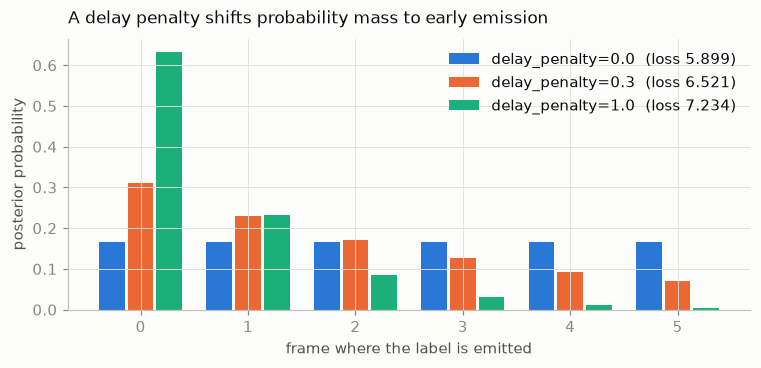

In [34]:
uniform = torch.full((6, 2, 3), -1.0986).log_softmax(dim=-1)  # T=6, U=1, V=3
one = torch.tensor([1])
penalties = [0.0, 0.3, 1.0]

fig, ax = plt.subplots(figsize=(8, 3.2))
width = 0.8 / len(penalties)
for k, pen in enumerate(penalties):
    ps = enumerate_paths(uniform, one, delay_penalty=pen)
    sc = torch.tensor([s for *_, s in ps])
    pp = (sc - sc.logsumexp(0)).exp()
    frame_prob = np.zeros(6)
    for (_, label_frames, _), p in zip(ps, pp):
        frame_prob[label_frames[0]] += float(p)
    loss = float(rnnt_loss(uniform[None], one[None], delay_penalty=pen))
    ax.bar(np.arange(6) + (k - 1) * width, frame_prob, width * 0.9,
           label=f"delay_penalty={pen}  (loss {loss:.3f})")
ax.set(xlabel="frame where the label is emitted", ylabel="posterior probability",
       title="A delay penalty shifts probability mass to early emission")
ax.legend(loc="upper right")
plt.show()

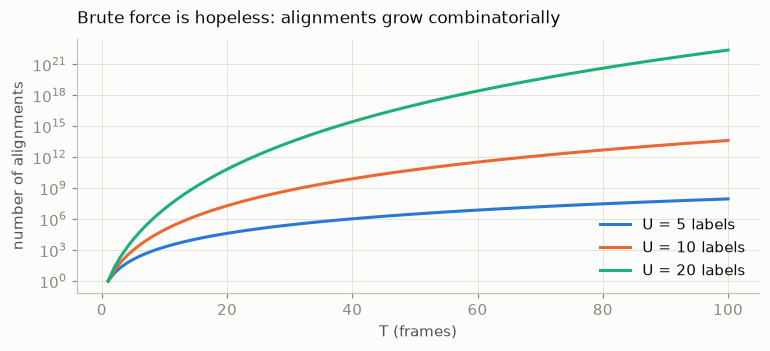

In [35]:
Ts = np.arange(1, 101)
fig, ax = plt.subplots(figsize=(8, 3))
for U_ in (5, 10, 20):
    ax.semilogy(Ts, [num_alignments(int(t), U_) for t in Ts], label=f"U = {U_} labels")
ax.set(xlabel="T (frames)", ylabel="number of alignments",
       title="Brute force is hopeless: alignments grow combinatorially")
ax.legend(loc="lower right")
plt.show()

**Try this**
- Write the forward recursion yourself and plot `alpha` as a `T x (U+1)` heatmap. Compare with `rnnt_loss` in `transducer.py`.
- Train `TinyTransducer` on a toy target for a few hundred steps, then use `greedy_decode` emission frames in section 6.

## 5. CTC decode, in the right order and the wrong one

A realistic CTC posteriorgram is **peaky**: mostly blank, with a label firing for a frame or two.
Greedy decoding must *collapse repeats first, then strip blanks*, because a blank between two
identical labels means "two of these". See `docs/ctc.md`.

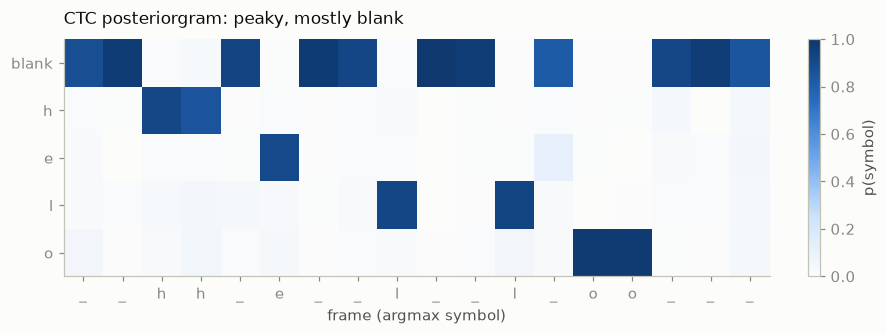

argmax per frame   __hh_e__l__l_oo___
right: collapse -> _h_e_l_l_o_    strip    -> hello
wrong: strip    -> hhelloo        collapse -> helo
peaky fraction (blank frames): 0.61


In [36]:
vocab = ["_", "h", "e", "l", "o"]  # 0 is blank
frame_path = "__hh_e__l__l_oo___"
ids = [vocab.index(ch) for ch in frame_path]

torch.manual_seed(0)
logits = 0.6 * torch.randn(len(ids), len(vocab))
logits[torch.arange(len(ids)), ids] += 4.0
lp = logits.log_softmax(-1)  # (T, V)

fig, ax = plt.subplots(figsize=(9, 2.8))
ax.grid(False)
im = ax.imshow(lp.exp().T, cmap=SEQ, vmin=0, vmax=1, aspect="auto")
ax.set_yticks(range(len(vocab)), ["blank"] + vocab[1:])
ax.set_xticks(range(len(ids)), list(frame_path))
ax.set(xlabel="frame (argmax symbol)", title="CTC posteriorgram: peaky, mostly blank")
fig.colorbar(im, ax=ax, label="p(symbol)", fraction=0.03)
plt.show()

show = lambda xs: "".join(vocab[i] for i in xs)
argmax = lp.argmax(-1).tolist()
collapsed = [k for k, _ in itertools.groupby(argmax)]
stripped = [i for i in argmax if i != 0]
print(f"argmax per frame   {show(argmax)}")
print(f"right: collapse -> {show(collapsed):<14} strip    -> {show(ctc_greedy_decode(lp))}")
print(f"wrong: strip    -> {show(stripped):<14} collapse -> {show(ctc_greedy_decode_buggy(lp))}")
print(f"peaky fraction (blank frames): {peaky_fraction(lp):.2f}")

In [37]:
# The CTC forward algorithm, checked against PyTorch's implementation
target = torch.tensor([vocab.index(c) for c in "hello"])
ours = float(ctc_loss_forward(lp, target))
ref = float(F.ctc_loss(lp[:, None, :], target[None], [lp.shape[0]], [len(target)], reduction="sum"))
print(f"ctc_loss_forward {ours:.5f}   torch.nn.functional.ctc_loss {ref:.5f}")

ctc_loss_forward 1.25113   torch.nn.functional.ctc_loss 1.25113


**Try this**
- Change `frame_path` so the two `l`s are adjacent with no blank between them. What does CTC decode now, and why can it never produce "hello" that way?
- Lower the `+= 4.0` peak height. At what point does the greedy decode start making mistakes?

## 6. Four latencies, and the one papers report

**Emission delay** is measured from each word's acoustic end to the frame where the decoder committed it.
These are worked numbers, as in the demo: an untrained model's emission times carry no information.

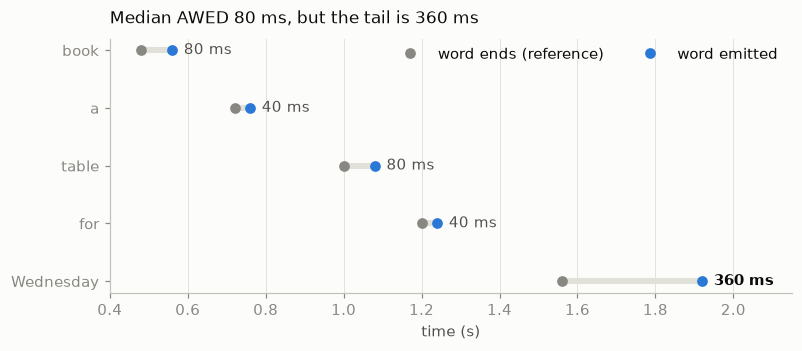

In [38]:
words = ["book", "a", "table", "for", "Wednesday"]
emitted_s = frames_to_seconds([14, 19, 27, 31, 48], FRAME_MS)
reference_s = frames_to_seconds([12, 18, 25, 30, 39], FRAME_MS)
delays_ms = [d * 1000 for d in emission_delays(emitted_s, reference_s)]

fig, ax = plt.subplots(figsize=(8, 3))
y = np.arange(len(words))[::-1]
ax.hlines(y, reference_s, emitted_s, color=GRID, lw=4)
ax.plot(reference_s, y, "o", color=MUTED, label="word ends (reference)")
ax.plot(emitted_s, y, "o", color=BLUE, label="word emitted")
for yi, e, d in zip(y, emitted_s, delays_ms):
    ax.text(e + 0.03, yi, f"{d:.0f} ms", va="center", color=INK if d > 200 else INK_2,
            fontweight="bold" if d > 200 else "normal")
ax.set_yticks(y, words)
ax.grid(axis="y", visible=False)
ax.set(xlabel="time (s)", xlim=(0.4, 2.15),
       title=f"Median AWED {awed(emitted_s, reference_s) * 1000:.0f} ms, but the tail is {max(delays_ms):.0f} ms")
ax.legend(loc="upper right", ncol=2, bbox_to_anchor=(1, 1.02))
plt.show()

A turn-final response adds up all four, plus the network. Comparing endpointing presets shows
which term really dominates.

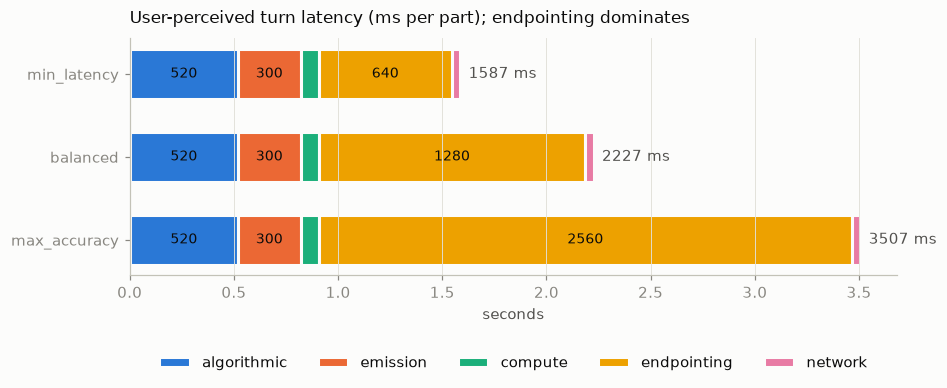

structural delay is 23% of the 'balanced' total


In [39]:
algorithmic = algorithmic_delay_seconds(14, FRAME_MS)
parts_order = ["algorithmic", "emission", "compute", "endpointing", "network"]
presets = ["min_latency", "balanced", "max_accuracy"]

breakdowns = {
    p: user_perceived_turn_latency(
        algorithmic_delay_s=algorithmic, emission_delay_s=0.30, rtfx=6.0,
        endpoint_silence_s=EndpointConfig.preset(p).max_turn_silence_ms / 1000.0,
        network_s=0.04,
    )
    for p in presets
}

fig, ax = plt.subplots(figsize=(9, 2.8))
ax.grid(axis="y", visible=False)
for i, part in enumerate(parts_order):
    left = [sum(breakdowns[p][q] for q in parts_order[:i]) for p in presets]
    vals = [breakdowns[p][part] for p in presets]
    bars = ax.barh(presets, vals, left=left, height=0.6, label=part,
                   color=[BLUE, ORANGE, AQUA, YELLOW, MAGENTA][i], edgecolor=SURFACE, linewidth=2)
    for b, v in zip(bars, vals):
        if v > 0.25:
            ax.text(b.get_x() + v / 2, b.get_y() + b.get_height() / 2, f"{v * 1000:.0f}",
                    ha="center", va="center", color=INK, fontsize=9)
for p in presets:
    ax.text(breakdowns[p]["total"] + 0.04, p, f"{breakdowns[p]['total'] * 1000:.0f} ms", va="center", color=INK_2)
ax.invert_yaxis()
ax.set(xlabel="seconds", title="User-perceived turn latency (ms per part); endpointing dominates")
ax.legend(ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.28))
plt.show()

print(f"structural delay is {algorithmic / breakdowns['balanced']['total']:.0%} of the 'balanced' total")

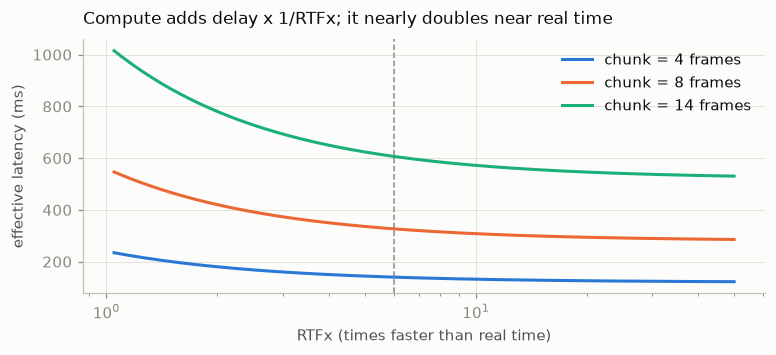

In [40]:
rtfx = np.geomspace(1.05, 50, 200)
fig, ax = plt.subplots(figsize=(8, 3))
for c in (4, 8, 14):
    a = algorithmic_delay_seconds(c, FRAME_MS)
    ax.semilogx(rtfx, [effective_latency(a, r) * 1000 for r in rtfx], label=f"chunk = {c} frames")
ax.axvline(6, color=MUTED, ls="--", lw=1)
ax.set(xlabel="RTFx (times faster than real time)", ylabel="effective latency (ms)",
       title="Compute adds delay x 1/RTFx; it nearly doubles near real time")
ax.legend(loc="upper right")
plt.show()

**Try this**
- Add a 90th-percentile delay to the emission chart's title. How far is it from the median?
- What RTFx does a 14-frame chunk need to stay under 600 ms effective latency?

## 7. Endpointing under an asymmetric loss

First, the demo's numbers: how long each preset waits after speech stops, depending on whether the
text so far *sounds* finished (the semantic signal).

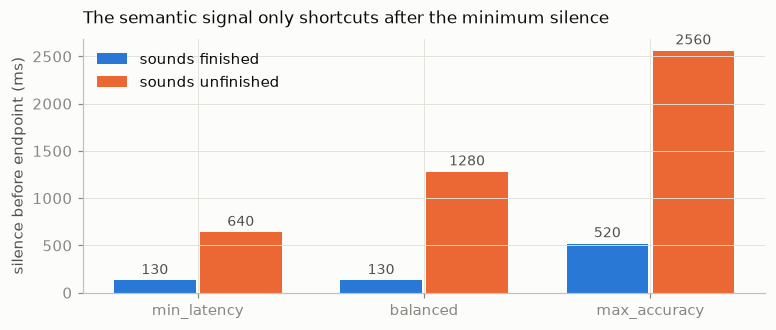

In [41]:
def fire_time_ms(preset, complete):
    ep = Endpointer(EndpointConfig.preset(preset), frame_ms=10.0)
    for _ in range(20):
        ep.update(0.9)
    for i in range(400):
        if ep.update(0.0, complete):
            return (i + 1) * 10
    return None


fig, ax = plt.subplots(figsize=(8, 3))
xs = np.arange(len(presets))
for k, (complete, label) in enumerate([(True, "sounds finished"), (False, "sounds unfinished")]):
    vals = [fire_time_ms(p, complete) for p in presets]
    bars = ax.bar(xs + (k - 0.5) * 0.38, vals, 0.36, label=label)
    ax.bar_label(bars, fmt="%d", padding=2, color=INK_2, fontsize=9)
ax.set_xticks(xs, presets)
ax.set(ylabel="silence before endpoint (ms)", title="The semantic signal only shortcuts after the minimum silence")
ax.legend(loc="upper left")
plt.show()

Now a whole utterance: speech, a **700 ms pause mid-sentence**, more speech, then final silence.
The grey area is the silence accumulator and hatched bands are speech. Vertical lines show where
each preset ends the turn. Mid-sentence the text sounds unfinished, so only `max_turn_silence`
applies there, and `min_latency` (640 ms) cuts the speaker off in both scenarios. After the last
word, the semantic signal decides whether `balanced` waits 128 ms or 1280 ms.

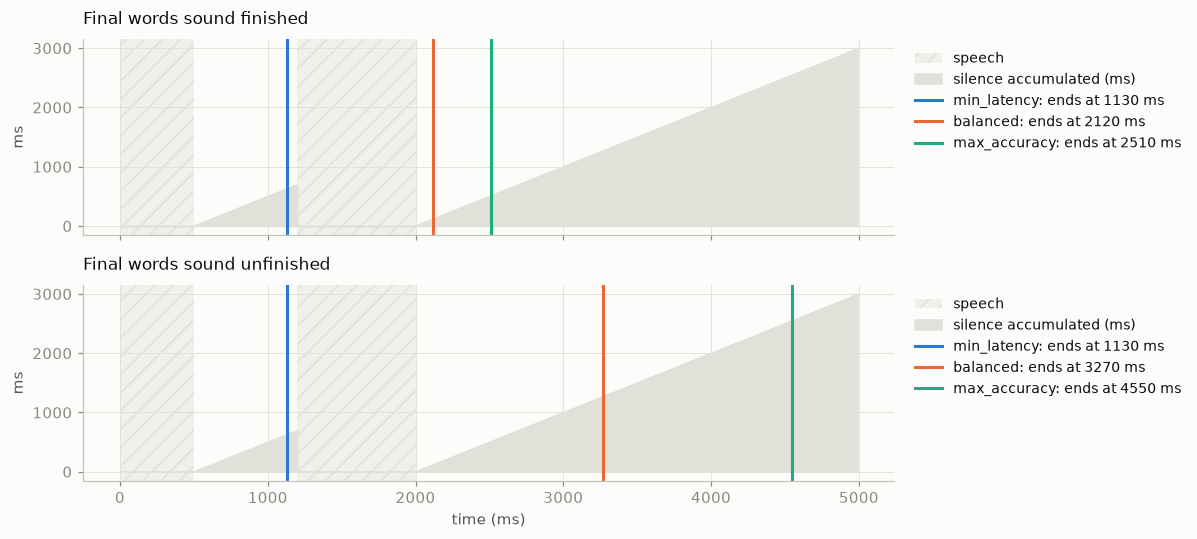

In [42]:
FRAME = 10  # ms


def make_trace(final_sounds_complete):
    segs = [(500, 0.9, False), (700, 0.05, False), (800, 0.9, False), (3000, 0.05, final_sounds_complete)]
    vad, complete = [], []
    for dur, p, c in segs:
        vad += [p] * (dur // FRAME)
        complete += [c] * (dur // FRAME)
    return np.array(vad), complete


def run(preset, vad, complete):
    ep = Endpointer(EndpointConfig.preset(preset), frame_ms=FRAME)
    for i, (p, c) in enumerate(zip(vad, complete)):
        if ep.update(p, c):
            return i * FRAME
    return None


fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
for ax, sounds_done in zip(axes, (True, False)):
    vad, complete = make_trace(sounds_done)
    t = np.arange(len(vad)) * FRAME
    silence = np.zeros(len(vad))
    for i in range(1, len(vad)):
        silence[i] = 0 if vad[i] >= 0.2 else silence[i - 1] + FRAME
    for s, e in [(0, 500), (1200, 2000)]:
        ax.axvspan(s, e, facecolor=NEUTRAL, hatch="//", edgecolor=GRID, lw=0, zorder=0,
                   label="speech" if s == 0 else None)
    ax.fill_between(t, silence, color=GRID, step="post", label="silence accumulated (ms)")
    for k, p in enumerate(presets):
        fired = run(p, vad, complete)
        ax.axvline(fired, color=[BLUE, ORANGE, AQUA][k], lw=2, label=f"{p}: ends at {fired} ms")
    ax.set(ylabel="ms", title=f"Final words {'sound finished' if sounds_done else 'sound unfinished'}")
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=9)
axes[1].set_xlabel("time (ms)")
plt.tight_layout()
plt.show()

**Try this**
- Use `Endpointer.set_config` to switch to `max_accuracy` while the user is reading out a phone number, then back.
- Shorten the mid-sentence pause until `min_latency` stops cutting in. What is the threshold, and which config value sets it?

## 8. Why the encoder cache is bounded and the LLM cache is not

The encoder keeps a fixed left-context window, while a decoder-only model keeps every frame.
Note the log scale.

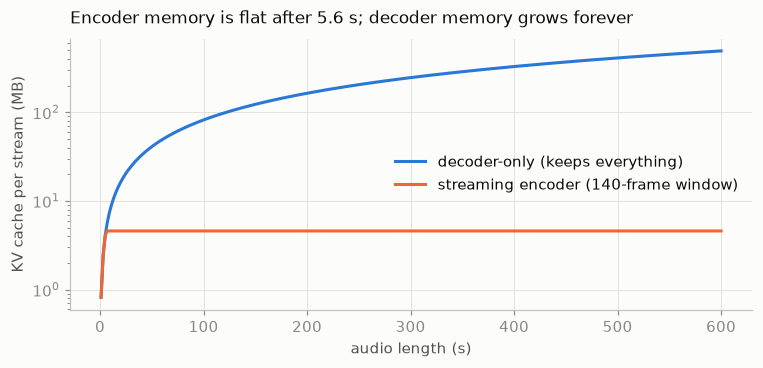

In [43]:
cfg = dict(num_layers=16, num_kv_heads=8, head_dim=64, dtype_bytes=2)
window = 140  # left context, frames
seconds = np.linspace(1, 600, 300)
frames = (seconds * 1000 / FRAME_MS).astype(int)
enc_mb = [kv_cache_bytes(seq_len=min(f, window), **cfg) / 1e6 for f in frames]
llm_mb = [kv_cache_bytes(seq_len=f, **cfg) / 1e6 for f in frames]

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.semilogy(seconds, llm_mb, label="decoder-only (keeps everything)")
ax.semilogy(seconds, enc_mb, label=f"streaming encoder ({window}-frame window)")
ax.set(xlabel="audio length (s)", ylabel="KV cache per stream (MB)",
       title="Encoder memory is flat after 5.6 s; decoder memory grows forever")
ax.legend(loc="center right")
plt.show()

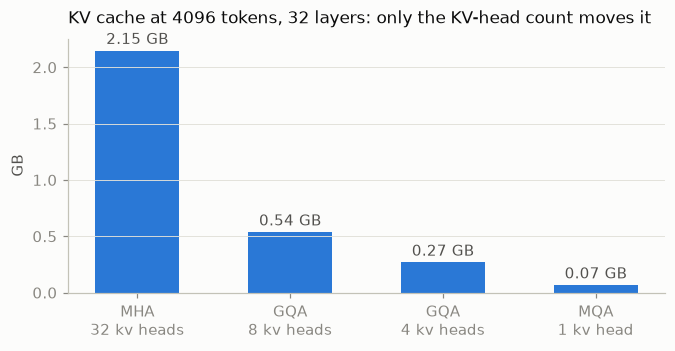

In [44]:
heads = {"MHA\n32 kv heads": 32, "GQA\n8 kv heads": 8, "GQA\n4 kv heads": 4, "MQA\n1 kv head": 1}
gb = [kv_cache_bytes(32, h, 128, 4096) / 1e9 for h in heads.values()]

fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.bar(list(heads), gb, width=0.55, color=BLUE)
ax.bar_label(bars, fmt="%.2f GB", padding=2, color=INK_2)
ax.grid(axis="x", visible=False)
ax.set(ylabel="GB", title="KV cache at 4096 tokens, 32 layers: only the KV-head count moves it")
plt.show()

**Try this**
- Halve the frame rate (`FRAME_MS = 80`). What happens to both curves?
- Compute the memory for 1,000 concurrent 10-minute calls in each design.

## Where to go next

- Copy this notebook to `02_<topic>.ipynb` and go deep on one module.
- Read the matching test in `tests/` alongside each section. The tests are the spec.